# Simple Linear Regression


Estimated time needed: **15-30** minutes
    

## Objectives

After completing this lab you will be able to:

* Use scikit-learn to implement simple Linear Regression
* Create a model, train it, test it and use the model


### Importing Needed packages


In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

### Downloading Data
To download the data, we will use !wget to download it from IBM Object Storage.


In [66]:
!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In case you're working **locally** uncomment the below line. 


In [67]:
!curl https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv -o FuelConsumptionCo2.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 72629  100 72629    0     0  44415      0  0:00:01  0:00:01 --:--:-- 44503



## Understanding the Data

### `FuelConsumption.csv`:
We have downloaded a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODELYEAR** e.g. 2014
- **MAKE** e.g. Acura
- **MODEL** e.g. ILX
- **VEHICLE CLASS** e.g. SUV
- **ENGINE SIZE** e.g. 4.7
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. A6
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 9.9
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 8.9
- **FUEL CONSUMPTION COMB (L/100 km)** e.g. 9.2
- **CO2 EMISSIONS (g/km)** e.g. 182   --> low --> 0


## Reading the data in


In [68]:


fuel_consumption_Co2 = pd.read_csv(r"C:\Users\User\Desktop\AI Engineering\LABs\lab-simple-linear-regression\FuelConsumptionCo2.csv")
# data loaded as pandas structure
## take a look at the dataset
print(fuel_consumption_Co2) # prints all dataset


      MODELYEAR   MAKE       MODEL    VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0          2014  ACURA         ILX         COMPACT         2.0          4   
1          2014  ACURA         ILX         COMPACT         2.4          4   
2          2014  ACURA  ILX HYBRID         COMPACT         1.5          4   
3          2014  ACURA     MDX 4WD     SUV - SMALL         3.5          6   
4          2014  ACURA     RDX AWD     SUV - SMALL         3.5          6   
...         ...    ...         ...             ...         ...        ...   
1062       2014  VOLVO    XC60 AWD     SUV - SMALL         3.0          6   
1063       2014  VOLVO    XC60 AWD     SUV - SMALL         3.2          6   
1064       2014  VOLVO    XC70 AWD     SUV - SMALL         3.0          6   
1065       2014  VOLVO    XC70 AWD     SUV - SMALL         3.2          6   
1066       2014  VOLVO    XC90 AWD  SUV - STANDARD         3.2          6   

     TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0 

In [69]:
print(fuel_consumption_Co2.shape)  # row, columns
print(fuel_consumption_Co2.dtypes) # data types per column
fuel_consumption_Co2.head() # print first few rows

(1067, 13)
MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Data Exploration
Let's first have a descriptive exploration on our data.


In [70]:
# summarize the data
# summarize all columns (numeric & categorical)

fuel_consumption_Co2.describe() # Shows: count, mean, std, min, 25%, 50%, 75%, max.

## fuel_consumption_Co2.describe(include="all")
    # For object/categorical columns you’ll see: 
    #  count, unique, top (most frequent), freq.


,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Let's select some features to explore more.


In [71]:
 
cdf = fuel_consumption_Co2[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
### makes a column subset (a new DataFrame) from fuel_consumption_Co2 Df
#   looks up those four columns by name
#   builds a new DataFrame called cdf that contains only them, in that order

print(cdf.shape)    # rows, 4
print(cdf.dtypes)   # types per column
cdf.head(9)     # shows first 9 rows

(1067, 4)
ENGINESIZE              float64
CYLINDERS                 int64
FUELCONSUMPTION_COMB    float64
CO2EMISSIONS              int64
dtype: object


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


We can plot each of these features:


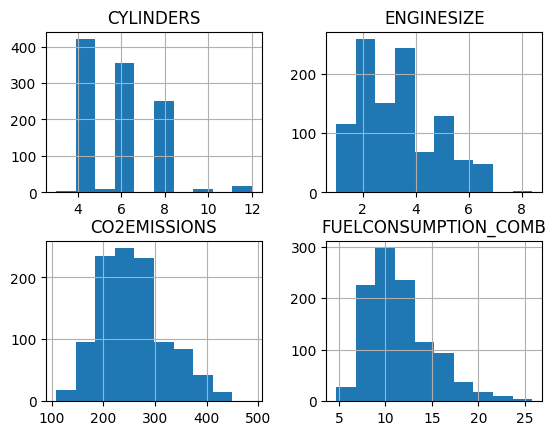

In [72]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
### creates a subset DataFrame named 'viz' by selecting 
#   four columns from 'cdf'(and putting them in this order)
#   This: keeps only the variables you want to visualize together
#   All four should be numeric for histograms; if not coerce/clean first

viz.hist()
### calls pandas'built-in histogram helper (uses Matplotlib)
#   creates one histogram per colum of 'viz', arranged in a grid of subplots
#   Default behaviour:
#       # uses a reasonable default number of bins (often 10)
#       # Ignores NaNs automatically
#       # Each subplot has its own x-axis labelled with the column name

plt.show()
### Tells Mathplotlib to render the figure to the screen (notebook)
#   without this call in some environments, the plots might not display

Now, let's plot each of these features against the Emission, to see how linear their relationship is:


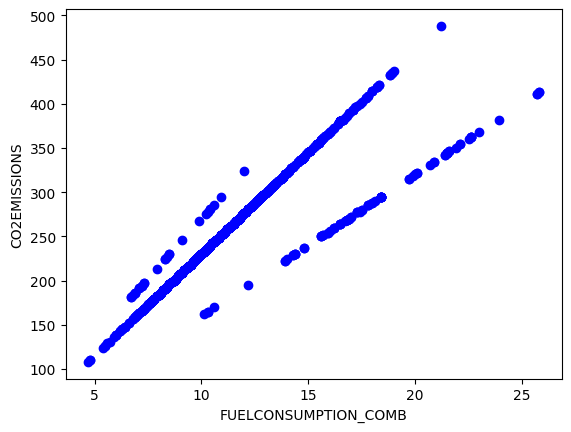

In [73]:
##  plt.scatter(x, y, ...) makes a scatter plot: 
#   each row in 'cdf' becomes a dot at (x,y)
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
    ##  cdf.FUELCONSUMPTION_COMB -> the x-values(combined fuel consumption)
    ##  cdf.CO2EMISSIONS -> the y-values (emissions)
    ##  colour='blue'colours the points 
    ##  cdf['FUELCONSUMPTION_COMB'] and cdf['CO2EMISSIONS'] are safer 
    #   if column names have spaces or special chars.
    ##  Matplotlib/pandas will ignore NaNs automatically, so rows 
    #   with missing x or y are skipped
plt.xlabel("FUELCONSUMPTION_COMB") # sets the x-axis label; clearly named
plt.ylabel("CO2EMISSIONS")  # sets the y-axis label; clearly named
plt.show() # Renders the scatter plot to screen/output. 

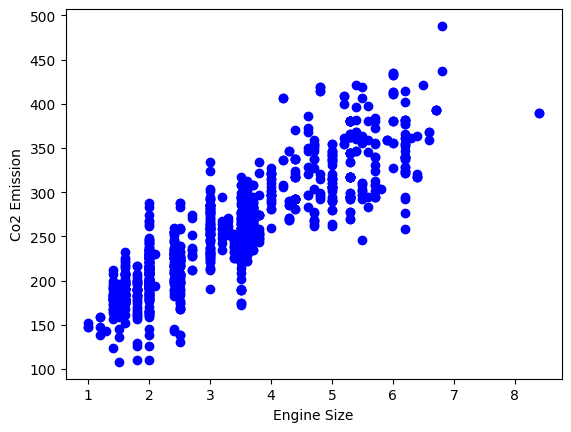

In [74]:
##  plt.scatter(x, y, ...) makes a scatter plot: 
#   each row in 'cdf' becomes a dot at (x,y)
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
    ##  cdf.ENGINESIZE -> the x-values(enginesize)
    ##  cdf.CO2EMISSIONS -> the y-values (Co2 emissions)
    ##  colour='blue'colours the points 
    ##  cdf['ENGINESIZE'] and cdf['CO2EMISSIONS'] are safer 
    #   if column names have spaces or special chars.
    ##  Matplotlib/pandas will ignore NaNs automatically, so rows 
    #   with missing x or y are skipped
plt.xlabel("Engine Size")   # sets the x-axis label; clearly named
plt.ylabel("Co2 Emission")  # sets the y-axis label; clearly named
plt.show()  # Renders the scatter plot to screen/output.

## Practice
Plot __CYLINDER__ vs the Emission, to see how linear is their relationship is:


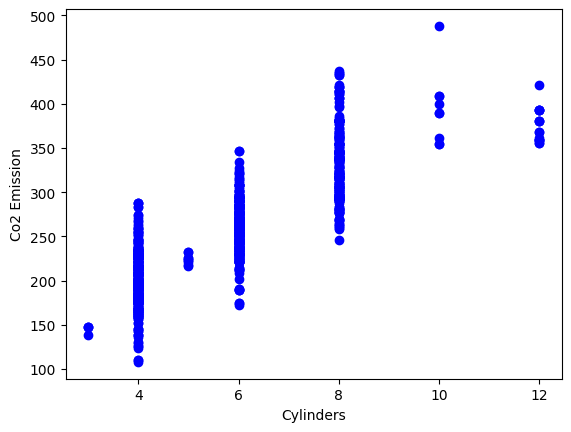

In [75]:
##  plt.scatter(x, y, ...) makes a scatter plot: 
#   each row in 'cdf' becomes a dot at (x,y)
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
    ##  cdf.CYLINDERS -> the x-values(Cylinders)
    ##  cdf.CO2EMISSIONS -> the y-values (Co2 emissions)
    ##  colour='blue'colours the points 
    ##  cdf['CYLINDERS'] and cdf['CO2EMISSIONS'] are safer 
    #   if column names have spaces or special chars.
    ##  Matplotlib/pandas will ignore NaNs automatically, so rows 
    #   with missing x or y are skipped
plt.xlabel("Cylinders")   # sets the x-axis label; clearly named
plt.ylabel("Co2 Emission")  # sets the y-axis label; clearly named
plt.show()  # Renders the scatter plot to screen/output.


<details><summary>Click here for the solution</summary>

```python    
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

```

</details>


#### Creating train and test dataset
Train/Test Split involves splitting the dataset into training and testing sets that are mutually exclusive. After which, you train with the training set and test with the testing set. 
This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the model. Therefore, it gives us a better understanding of how well our model generalizes on new data.

This means that we know the outcome of each data point in the testing dataset, making it great to test with! Since this data has not been used to train the model, the model has no knowledge of the outcome of these data points. So, in essence, it is truly an out-of-sample testing.

Let's split our dataset into train and test sets. 80% of the entire dataset will be used for training and 20% for testing. We create a mask to select random rows using __np.random.rand()__ function: 


In [76]:
import numpy as np
np.random.seed(0)   # Optional: make results reproducible; set a seed

### This is the CLASSIC RANDOM MASK SPLIT (Boolean mask; random numbers)
msk = np.random.rand(len(cdf)) < 0.8
##  creates a 1D array of random numbers in [0,1];
##  length = the dataset - len(cdf)
##  comparing to 0.8 yields gives a boolean mask with ~80% True; ~20% False
 
train = cdf[msk] # select rows where mask is True into train
test = cdf[~msk] # select rows where mask is False into test; ~msk - flips the boolean (True into False)

### Simple Regression Model
Linear Regression fits a linear model with coefficients B = (B1, ..., Bn) to minimize the 'residual sum of squares' between the actual value y in the dataset, and the predicted value yhat using linear approximation. 


#### Train data distribution


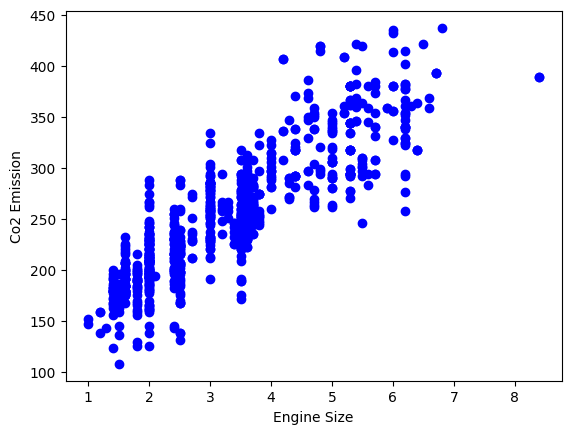

In [77]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Co2 Emission")
plt.show()

#### Modeling
Using sklearn package to model data.


In [78]:
### Ensure columns are numeric and contain no NaNs before fitting:
# 1. Inspect current types
print(train.dtypes[['ENGINESIZE', 'CO2EMISSIONS']])

# 2. Coerce to numeric (rurns bad tokens like "?" into Nan)
print(train[['ENGINESIZE', 'CO2EMISSIONS']].isna().sum())

ENGINESIZE      float64
CO2EMISSIONS      int64
dtype: object
ENGINESIZE      0
CO2EMISSIONS    0
dtype: int64


In [79]:
from sklearn import linear_model #import scikit-learn's linear model
regr = linear_model.LinearRegression() 
#   creates Linear Regression extimator named 'regr' 
#   model will learn an intercept and slope(s)

## Build the feature matrix:train_X and target vector: train_y from train DataFrame: cdf
## train[['ENGINESIZE']] - keeps the column as a 2D DataFrame - shape (n_samples,1)
## np.asanarray(...) - converts to numpy array, while preserving subclasses if present
## ....it gives you an array of shapes:
## train_x.shape == (n_samples, 1)
## train_y.shape == (n_samples, 1) since you selected it as a 2D column
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

## FIT/Train the model on training data 'train'
##  finds coefficients that minimize the sum of squared residuals 
#   b/n actual CO2EMISSIONS and predicted values from ENGINESIZE
regr.fit(train_x, train_y)

# After fitting:
print ('Coefficients: ', regr.coef_) 
# regr.coef_ is the learned slope; 
# shape of this one (1,1): change of Co2 emissions per unit increase in engine change
print ('Intercept: ',regr.intercept_)
# regr.intercept_ is the learned baseline Co2 when Enginesize = 0
# shape (1, ) depending on y-shape

Coefficients:  [[38.3331378]]
Intercept:  [127.44970828]


As mentioned before, __Coefficient__ and __Intercept__ in the simple linear regression, are the parameters of the fit line. 
Given that it is a simple linear regression, with only 2 parameters, and knowing that the parameters are the intercept and slope of the line, sklearn can estimate them directly from our data. 
Notice that all of the data must be available to traverse and calculate the parameters.


#### Plot outputs


In [80]:
### Prediction Formula: CO2=b0​+b1*ENGINESIZE
#   b0 = Intercept
#   b1 = Coefficients

We can plot the fit line over the data:


Text(0, 0.5, 'Emission')

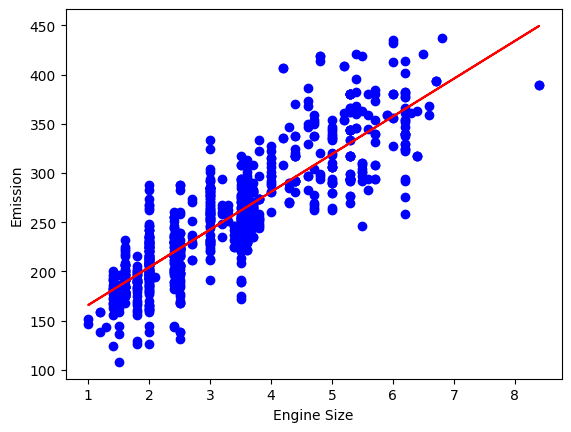

In [81]:
# draw a scatter plot of training data ; visualize the raw relationships
# x-values: train.ENGINESIZE ; y-values: train.CO2EMISSIONS
# colour = 'blue' points are blue
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
# Overlays the fitted regression line in red ('-r') on top of the scatter
# train_x is your feature array you fit on; in your earlier code it’s a 2D array with shape (n_samples, 1)
# regr.coef_[0][0] is the learned slope (since it’s a simple regression with one feature, coef_ has shape (1, 1))
# regr.intercept_[0] is the learned intercept (stored as a 1-element array because you fit with a 2D y)
# The expression regr.coef_[0][0] * train_x + regr.intercept_[0] computes the predicted y for each x in train_x, 
# giving the straight line y = b0 + b1*x

plt.xlabel("Engine Size") # sets x-axis label
plt.ylabel("Emission")    # sets y-axis label

#### Evaluation
We compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics provide a key role in the development of a model, as it provides insight to areas that require improvement.

There are different model evaluation metrics, lets use MSE here to calculate the accuracy of our model based on the test set: 
* Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just average error.

* Mean Squared Error (MSE): Mean Squared Error (MSE) is the mean of the squared error. It’s more popular than Mean Absolute Error because the focus is geared more towards large errors. This is due to the squared term exponentially increasing larger errors in comparison to smaller ones.

* Root Mean Squared Error (RMSE). 

* R-squared is not an error, but rather a popular metric to measure the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R-squared value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


In [82]:
from sklearn.metrics import r2_score
## Imports the R² metric function. 
# R² (coefficient of determination) measures how much 
# variance in the target is explained by the model 
# (1.0 = perfect, 0 = no better than predicting the mean; 
# it can be negative).
test_x = np.asanyarray(test[['ENGINESIZE']]) # builds test feature matrix from test Dataframe
test_y = np.asanyarray(test[['CO2EMISSIONS']]) # builds the test target array from the test DataFrame
# test[['ENGINESIZE']] and test[['CO2EMISSIONS']] keep 
# the data 2D (shape (n_samples, 1)), which matches how you trained
# np.asanyarray(...) converts to NumPy arrays
test_y_ = regr.predict(test_x) 
# Uses the fitted model regr to predict CO₂ emissions for:
# the unseen test features test_x
# test_y_ has shape (n_samples, 1) (since you trained with a 2D y earlier)

print("Mean absolute error (MAE): %.2f" % np.mean(np.absolute(test_y_ - test_y)))
# MAE (Mean Absolute Error): average absolute difference between predicted and true values
# test_y_ - test_y → residuals (prediction error for each row)
# np.absolute(...) → absolute errors
# np.mean(...) → average absolute error
# Lower is better; 
# units are the same as the target (here, CO₂ emission units)
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
# MSE (Mean Squared Error): average of squared residuals
# Squaring penalizes larger errors more strongly
# Sometimes people print RMSE (square root of MSE) to get back to the original units
print("R2-score: %.2f" % r2_score(test_y , test_y_))
# Computes R² by comparing the true test targets (test_y) to predictions (test_y_)
# Interprets how much of the variance in CO₂ emissions the model explains on the test set
# Closer to 1.00 is better; 
# 0.00 ~ predicting the mean; 
# negative = worse than the mean predictor


Mean absolute error (MAE): 23.56
Residual sum of squares (MSE): 946.76
R2-score: 0.79


In [83]:
rmse = np.sqrt(np.mean((test_y_ - test_y) ** 2))
print("Root Mean Squared Error - RMSE: %.2f" % rmse)
# test_y_ - test_y → residuals (prediction error for each row)
# ** 2 → square each residual (penalizes big errors more)
# np.mean(...) → take the average of those squared errors → this is the MSE
# np.sqrt(...) → take the square root of MSE → RMSE (root mean squared error)

Root Mean Squared Error - RMSE: 30.77


## Exercise


Lets see what the evaluation metrics are if we trained a regression model using the `FUELCONSUMPTION_COMB` feature.

Start by selecting `FUELCONSUMPTION_COMB` as the train_x data from the `train` dataframe, then select `FUELCONSUMPTION_COMB` as the test_x data from the `test` dataframe


In [84]:
# (optional) ensure numeric & coerce bad tokens to NaN
train['FUELCONSUMPTION_COMB'] = pd.to_numeric(train['FUELCONSUMPTION_COMB'], errors='coerce')
test['FUELCONSUMPTION_COMB']  = pd.to_numeric(test['FUELCONSUMPTION_COMB'],  errors='coerce')

train_x = np.asanyarray(train[['FUELCONSUMPTION_COMB']]) #shape: (n_train, 1)

test_x = np.asanyarray(test[['FUELCONSUMPTION_COMB']]) #shape: (n_test, 1)
#[['FUELCONSUMPTION_COMB']] (double brackets) keeps a 2D array,
# which scikit-learn expects for features
# The optional coercion/drop ensures no NaN/type errors when 
# fitting and predicting

C:\Users\User\AppData\Local\Temp\ipykernel_17064\1729143854.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['FUELCONSUMPTION_COMB'] = pd.to_numeric(train['FUELCONSUMPTION_COMB'], errors='coerce')
C:\Users\User\AppData\Local\Temp\ipykernel_17064\1729143854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['FUELCONSUMPTION_COMB']  = pd.to_numeric(test['FUELCONSUMPTION_COMB'],  errors='coerce')


In [85]:
## Pandas is warning that train and test are likely views (slices) 
#  of another DataFrame (e.g., cdf), not independent copies
## the assignment might not change the original the way you expect 
# (or might silently fail), because it’s a “chained assignment” on a view

<details><summary>Click here for the solution</summary>

```python    
train_x = train[["FUELCONSUMPTION_COMB"]]

test_x = test[["FUELCONSUMPTION_COMB"]]

```

</details>


Now train a Linear Regression Model using the `train_x` you created and the `train_y` created previously


In [86]:
from sklearn import linear_model
regr = linear_model.LinearRegression()  ## model initialized

regr.fit(train_x, train_y)  ## fit on training data created previously

# (optional) quick checks
print("Intercept:", regr.intercept_)
print("Coefficient(s):", regr.coef_)

Intercept: [64.43008508]
Coefficient(s): [[16.57360216]]


<details><summary>Click here for the solution</summary>

```python    
regr = linear_model.LinearRegression()

regr.fit(train_x, train_y)

```

</details>


Find the predictions using the model's `predict` function and the `test_x` data


In [87]:
predictions = regr.predict(test_x)
# regr is the LinearRegression fit on (train_x, train_y)
# test_x is the 2D array of FUELCONSUMPTION_COMB from the test set.
# predictions will be a NumPy array of predicted 
# ...CO2EMISSIONS for each row in test_x.

<details><summary>Click here for the solution</summary>

```python    
predictions = regr.predict(test_x)

```

</details>


Finally use the `predictions` and the `test_y` data and find the Mean Absolute Error value using the `np.absolute` and `np.mean` function like done previously


In [91]:
mae = np.mean(np.absolute(predictions - test_y))
print("Mean Absolute Error (MAE):", float(mae))
# predictions - test_y → vector of residuals.
# np.absolute(...) → absolute errors.
# np.mean(...) → average absolute error (MAE).
# float(mae) just pretty-prints if it’s a 0-d array. 
# If test_y is a pandas Series, this code works the same.


Mean Absolute Error (MAE): 22.95161636117775


<details><summary>Click here for the solution</summary>

```python    
print("Mean Absolute Error: %.2f" % np.mean(np.absolute(predictions - test_y)))

```

</details>


We can see that the MAE is much worse when we train using `ENGINESIZE` than `FUELCONSUMPTION_COMB`


### Repeat everything you did using two additional regression models [optional]

### Thank you for completing the lab!